In [62]:
# MU-Glioma-Post data

import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Setup paths
segmentation_volumes_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx"
clinical_data_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx"
image_data_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post"

# 2. Load Clinical Data
clinical_data = pd.ExcelFile(clinical_data_path)
for sheet in clinical_data.sheet_names:
    df = pd.read_excel(clinical_data_path, sheet_name=sheet)
    print(f"Sheet: {sheet} | Patients: {len(df)} | Columns: {df.columns.tolist()}")


Sheet: Data Dictionary | Patients: 184 | Columns: ['Data Collection Name', 'Data Descriptor /Metadata Name']
Sheet: MU Glioma Post | Patients: 203 | Columns: ['Patient ID', 'Sex at Birth', 'Race', 'Age at diagnosis', 'Primary Diagnosis', 'Grade of Primary Brain Tumor', 'Stereotactic Biopsy before Surgical Resection', 'Progression', 'Time to First Progression (Days)', 'Type of 1st Progression', 'Second Progression/Recurrence', 'Type of 2nd Progression', 'Multiple surgeries', 'Hospice', 'Overall Survival (Death)', 'Number of days from Diagnosis to death (Days)', 'IDH1 mutation', 'IDH2 mutation', '1p/19q', 'ATRX mutation', 'MGMT methylation', 'BRAF V600E mutation', 'TERT promoter mutation', 'Chromosome 7 gain and Chromosome 10 loss', 'H3-3A mutation', 'EGFR amplification', 'PTEN mutation', 'CDKN2A/B deletion', 'TP53 alteration', 'Other mutations/alterations', 'Previous Brain Tumor', 'Type of previous brain tumor', 'Year of previous surgery', 'Grade of Previous brain tumor', 'Number of day

In [ ]:
# 3. Get Patient IDs from Image Data
patient_ids = [d for d in os.listdir(image_data_path) 
               if os.path.isdir(os.path.join(image_data_path, d)) and not d.startswith('.')]
patient_ids.sort()

# 4. Iterate through each Patient for timepoint and image verification
for pid in patient_ids:
    patient_folder_path = os.path.join(image_data_path, pid)
    
    # Get Timepoint folders
    timepoints = sorted([t for t in os.listdir(patient_folder_path) 
                        if os.path.isdir(os.path.join(patient_folder_path, t)) and not t.startswith('.')])
    
    print(f"\n" + "="*100)
    print(f"Patient ID: {pid} | Timepoints: {timepoints}")
    print("="*100)

    for timepoint in timepoints:
        timepoint_folder_path = os.path.join(patient_folder_path, timepoint)
        
        # Get all .nii.gz files in the folder
        image_files = sorted([f for f in os.listdir(timepoint_folder_path) 
                              if f.endswith('.nii.gz') and not f.startswith('.')])
        
        if not image_files:
            print(f"   ⚠️ No images found in {timepoint}")
            continue

        # Create a grid to show every image found in the folder
        num_images = len(image_files)
        fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))
        if num_images == 1: axes = [axes] # Handle single image case
        
        fig.suptitle(f"Patient: {pid}", fontsize=14)

        for i, f_name in enumerate(image_files):
            file_path = os.path.join(timepoint_folder_path, f_name)
            img = nib.load(file_path)
            data = img.get_fdata()
            
            # Show the middle slice (standard for raw data inspection)
            slice_idx = data.shape[2] // 2
            
            axes[i].imshow(np.rot90(data[:, :, slice_idx]), cmap='gray')
            axes[i].set_title(f_name.split('.')[0], fontsize=10)
            axes[i].axis('off')
            
        plt.tight_layout()
        plt.show()

In [67]:
# Image and Segmentation Data - Verify existence of NIfTI files for each patient and timepoint

# 1. PATHS
segmentation_volume_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx"

# 3. LOAD SEGMENTATION VOLUMES (All Sheets)
segmentation_volumes = pd.ExcelFile(segmentation_volume_path)
volume_data = {}

for sheet in segmentation_volumes.sheet_names:
    # Read the sheet and clean column names
    df = pd.read_excel(segmentation_volume_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    
    # Standardize column name to Patient_ID
    if 'Patient ID' in df.columns:
        df = df.rename(columns={'Patient ID': 'Patient_ID'})
        
        # 1. GENERATE TIMEPOINT LABELS
        # Since the ID repeats, cumcount() assigns 0 to the 1st occurrence, 1 to the 2nd, etc.
        # We add 1 and convert to "Timepoint_X" to match your image folder names.
        df['Timepoint_Index'] = df.groupby('Patient_ID').cumcount() + 1
        df['Timepoint'] = "Timepoint_" + df['Timepoint_Index'].astype(str)
        
        # 2. Filter for only the patients found in your image folder (patient_ids list)
        df_filtered = df[df['Patient_ID'].isin(patient_ids)].copy()
        
        # 3. Store in the dictionary
        # We keep Patient_ID as the index, but Timepoint is now an explicit column
        volume_data[sheet] = df_filtered.set_index('Patient_ID')
        
        print(f"{sheet}: Found {len(df_filtered)} total scans for {df_filtered['Patient_ID'].nunique()} unique patients.")

Necrotic Tumor Core (Label1): Found 272 total scans for 119 unique patients.
Tumor Infiltration and Edema: Found 419 total scans for 145 unique patients.
Enhancing Tumor Core (Label3): Found 408 total scans for 144 unique patients.
Resection Cavity (Label4): Found 368 total scans for 135 unique patients.


In [87]:
import os
import nibabel as nib
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# =============================================================================
# 1. SETUP PATHS
# =============================================================================
seg_vol_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx"
image_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post"

# 2. EXTRACT PATIENT IDS FROM DIRECTORY
patient_ids = sorted([d for d in os.listdir(image_path) 
                     if os.path.isdir(os.path.join(image_path, d)) and not d.startswith('.')])

# =============================================================================
# 3. PROCESS SEGMENTATION VOLUMES (Store as Sequences for Positional Mapping)
# =============================================================================
print("📊 Extracting volumes and voxels as ordered sequences...")
volume_sequences = {} # Structure: { 'Label': { 'PatientID': [vol1, vol2, ...] } }
voxel_sequences = {}

seg_file = pd.ExcelFile(seg_vol_path)
label_map = {
    "Necrotic Tumor Core (Label1)": "Necrotic",
    "Tumor Infiltration and Edema": "Edema",
    "Enhancing Tumor Core (Label3)": "Enhancing",
    "Resection Cavity (Label4)": "Resection"
}

for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    
    if 'Patient ID' in df.columns:
        # Standardize naming
        df = df.rename(columns={'Patient ID': 'Patient_ID'})
        
        # Extract Clean ID (remove suffixes like -Post-treatment_3)
        # This allows us to group all rows belonging to the same person
        df['Patient_ID_Clean'] = df['Patient_ID'].str.split('-').str[0]
        
        # Identify numerical columns
        vox_col = 'Number Of Voxels' if 'Number Of Voxels' in df.columns else df.columns[3]
        vol_col = 'Volume (mm^3)' if 'Volume (mm^3)' in df.columns else df.columns[4]
        
        label_key = label_map.get(sheet, sheet)
        
        # Store data as a list for each patient to preserve the order of visits
        volume_sequences[label_key] = df.groupby('Patient_ID_Clean')[vol_col].apply(list).to_dict()
        voxel_sequences[label_key] = df.groupby('Patient_ID_Clean')[vox_col].apply(list).to_dict()

# =============================================================================
# 4. CONSTRUCT UNIFIED PATIENT OBJECTS (Mapped by Order)
# =============================================================================
print("🤖 Building integrated Patient objects by sequence order...")
patient_objects = {}

for pid in patient_ids:
    patient_folder = Path(image_path) / pid
    obj = {
        'Patient_ID': pid,
        'timepoints': [],
        'images': {}, 
        'volumes': {}, 
        'voxels': {}, 
        'total_volumes': {}
    }
    
    if patient_folder.exists():
        # Get sorted list of folders from your disk (e.g., [TP_1, TP_2, TP_5])
        tps = sorted([t.name for t in patient_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
        obj['timepoints'] = tps
        
        for i, tp in enumerate(tps):
            # A. Map Image Paths
            tp_path = patient_folder / tp
            obj['images'][tp] = [str(f) for f in tp_path.glob("*.nii*")]
            
            # B. Map Numerical Data by SEQUENCE INDEX (i)
            # This ensures Folder #3 (e.g. Timepoint_5) maps to Excel Row #3
            tp_vols = {}
            tp_vox = {}
            
            for label in volume_sequences.keys():
                # Get the sequence of values for this patient
                v_list = volume_sequences[label].get(pid, [])
                x_list = voxel_sequences[label].get(pid, [])
                
                # Check if the i-th folder has a corresponding i-th data point in Excel
                if i < len(v_list):
                    tp_vols[label] = float(v_list[i])
                    tp_vox[label] = int(x_list[i])
            
            # C. Store and Compute Biological Growth Totals
            if tp_vols:
                obj['volumes'][tp] = tp_vols
                obj['voxels'][tp] = tp_vox
                # Summing Necrotic + Edema + Enhancing + Resection for Physics-Informed Growth
                bio_v = tp_vols.get('Necrotic', 0) + tp_vols.get('Edema', 0) + tp_vols.get('Enhancing', 0) + tp_vols.get('Resection', 0)
                obj['total_volumes'][tp] = bio_v
            else:
                print(f"⚠️ Warning: No Excel data row found for {pid} at its {i+1}-th folder ({tp})")

    patient_objects[pid] = obj

📊 Extracting volumes and voxels as ordered sequences...
🤖 Building integrated Patient objects by sequence order...
⚠️ Warning: No Excel data row found for PatientID_0187 at its 3-th folder (Timepoint_3)
⚠️ Warning: No Excel data row found for PatientID_0191 at its 4-th folder (Timepoint_4)


In [90]:
# =============================================================================
# 5. DATA AUDIT SUMMARY - IMAGES & VOLUMES
# =============================================================================
# Check a sample patient (e.g., PatientID_0003) to verify the fix
sample_id = "PatientID_0005" 
if sample_id in patient_objects:
    patient = patient_objects[sample_id]
    print(f"\n" + "="*100)
    print(f"🧬 DATA AUDIT: {sample_id} | {len(patient['timepoints'])} Timepoints Found")
    print("="*100)

    for tp in patient['timepoints']:
        vols = patient['volumes'].get(tp, {})
        voxs = patient['voxels'].get(tp, {})
        total_vol = patient['total_volumes'].get(tp, 0)
        num_vox = sum(voxs.values()) if voxs else 0
        
        print(f"📊 {tp} SEGMENTATION METRICS:")
        for label in vols.keys():
            v = vols.get(label, 0)
            x = voxs.get(label, 0)
            print(f"   └─ {label:15}: {v:>10,.2f} mm³ ({x:>8,} voxels)")
        
        print(f"⭐ TOTAL TUMOR VOLUME:  {total_vol:>10,.2f} mm³")
        print(f"⭐ TOTAL VOXEL COUNT:   {num_vox:>10,}")
        print("-" * 100)


🧬 DATA AUDIT: PatientID_0005 | 2 Timepoints Found
📊 Timepoint_3 SEGMENTATION METRICS:
   └─ Necrotic       :   2,946.00 mm³ (   2,946 voxels)
   └─ Edema          :  93,727.00 mm³ (  93,727 voxels)
   └─ Enhancing      :  42,780.00 mm³ (  42,780 voxels)
⭐ TOTAL TUMOR VOLUME:  139,453.00 mm³
⭐ TOTAL VOXEL COUNT:      139,453
----------------------------------------------------------------------------------------------------
📊 Timepoint_4 SEGMENTATION METRICS:
   └─ Necrotic       :  10,541.00 mm³ (  10,541 voxels)
   └─ Edema          : 102,189.00 mm³ ( 102,189 voxels)
   └─ Enhancing      :  27,581.00 mm³ (  27,581 voxels)
⭐ TOTAL TUMOR VOLUME:  140,311.00 mm³
⭐ TOTAL VOXEL COUNT:      140,311
----------------------------------------------------------------------------------------------------



🧬 DATA AUDIT: PatientID_0003 | 3 Timepoints Found


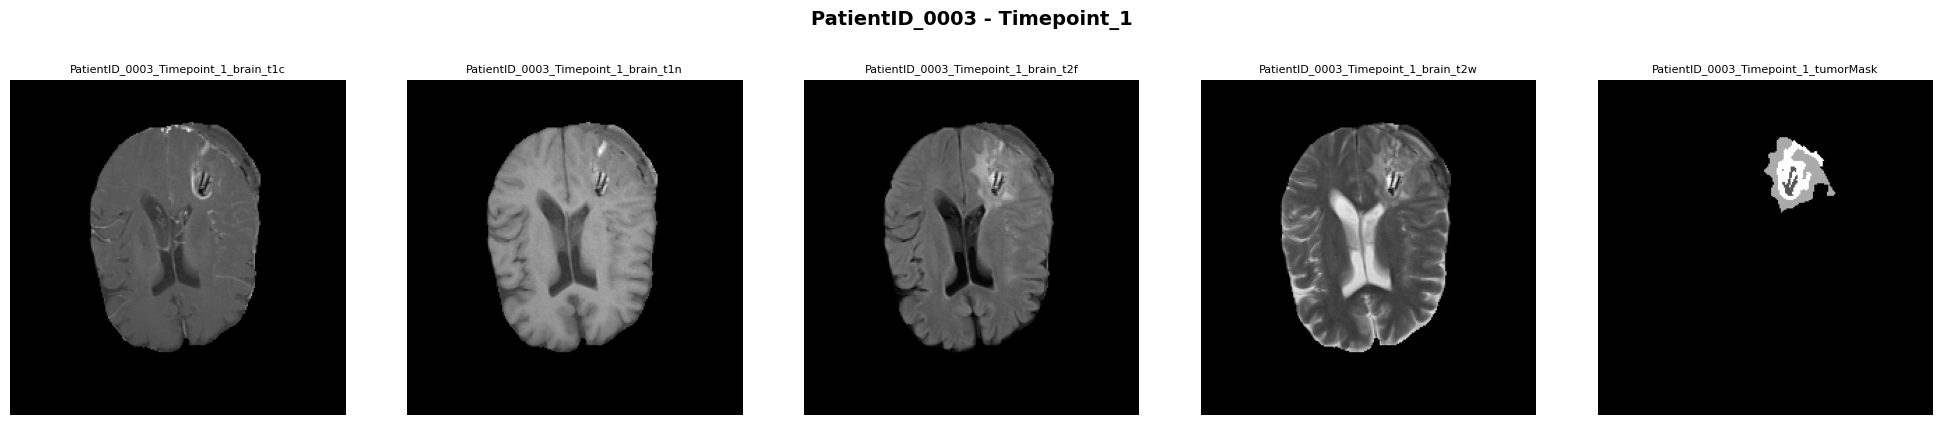

📊 Timepoint_1 SEGMENTATION METRICS:
   └─ Necrotic       :   6,510.00 mm³
   └─ Edema          :  44,251.00 mm³
   └─ Enhancing      :  33,779.00 mm³
TOTAL TUMOR VOLUME(mm³):    84,540.00 mm³
NUMBER OF VOXELS:            0
----------------------------------------------------------------------------------------------------


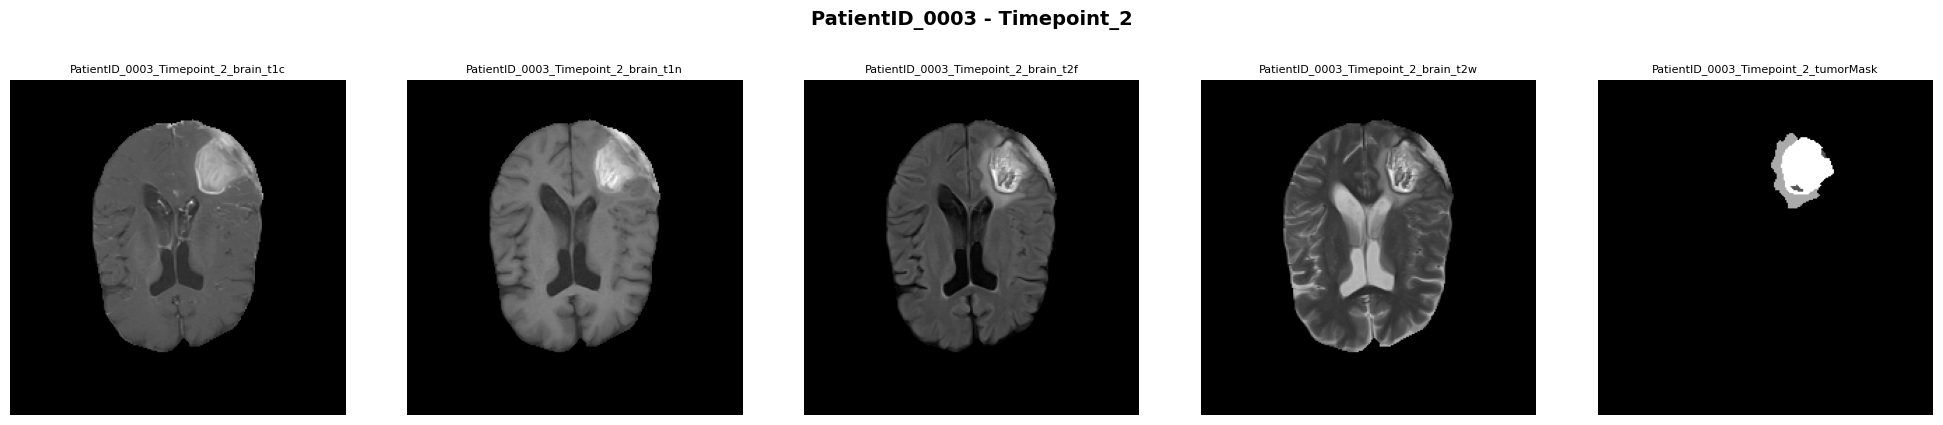

📊 Timepoint_2 SEGMENTATION METRICS:
   └─ Necrotic       :   2,813.00 mm³
   └─ Edema          :  45,757.00 mm³
   └─ Enhancing      :  37,248.00 mm³
TOTAL TUMOR VOLUME(mm³):    85,818.00 mm³
NUMBER OF VOXELS:            0
----------------------------------------------------------------------------------------------------


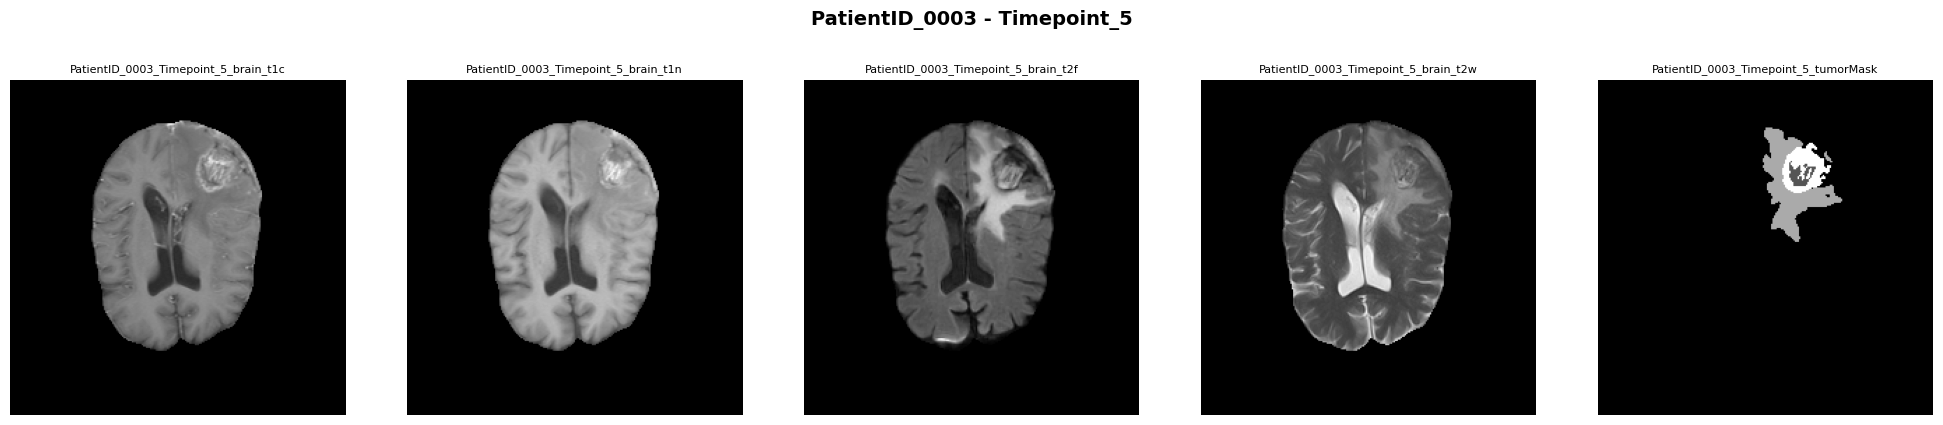

📊 Timepoint_5 SEGMENTATION METRICS:
   └─ Necrotic       :       0.00 mm³
   └─ Edema          :       0.00 mm³
   └─ Enhancing      :       0.00 mm³
TOTAL TUMOR VOLUME(mm³):         0.00 mm³
NUMBER OF VOXELS:            0
----------------------------------------------------------------------------------------------------


In [53]:
# =============================================================================
# 5. DATA AUDIT SUMMARY - IMAGES & VOLUMES
# =============================================================================
sample_id = patient_ids[0]
patient = patient_objects[sample_id]

print(f"\n" + "="*100)
print(f"🧬 DATA AUDIT: {sample_id} | {len(patient['timepoints'])} Timepoints Found")
print("="*100)

for tp in patient['timepoints']:
    images = sorted(patient['images'].get(tp, []))
    
    if images:
        # Create a grid for all scans in this timepoint
        num_imgs = len(images)
        fig, axes = plt.subplots(1, num_imgs, figsize=(4 * num_imgs, 4))
        if num_imgs == 1: axes = [axes]
        
        fig.suptitle(f"{sample_id} - {tp}", fontsize=14, fontweight='bold', y=1.05)
        
        for i, img_path in enumerate(images):
            data = nib.load(img_path).get_fdata()
            mid_slice = data.shape[2] // 2
            
            axes[i].imshow(np.rot90(data[:, :, mid_slice]), cmap='gray')
            axes[i].set_title(Path(img_path).name.replace('.nii.gz', ''), fontsize=8)
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()

    # Display Volume Metadata for the NODE-PINN
    vols = patient['volumes'].get(tp, {})
    voxs = patient['voxels'].get(tp, {})
    total_vol = patient['total_volumes'].get(tp, 0)
    num_vox = sum(voxs.values()) if voxs else 0

    
    print(f"📊 {tp} SEGMENTATION METRICS:")
    for label, val in vols.items():
        print(f"   └─ {label:15}: {val:>10,.2f} mm³")
    print(f"TOTAL TUMOR VOLUME(mm³):   {total_vol:>10,.2f} mm³")
    print(f"NUMBER OF VOXELS:   {num_vox:>10,}")
    print("-" * 100)


🧬 NODE-PINN TRAINING DATA AUDIT: PatientID_0003


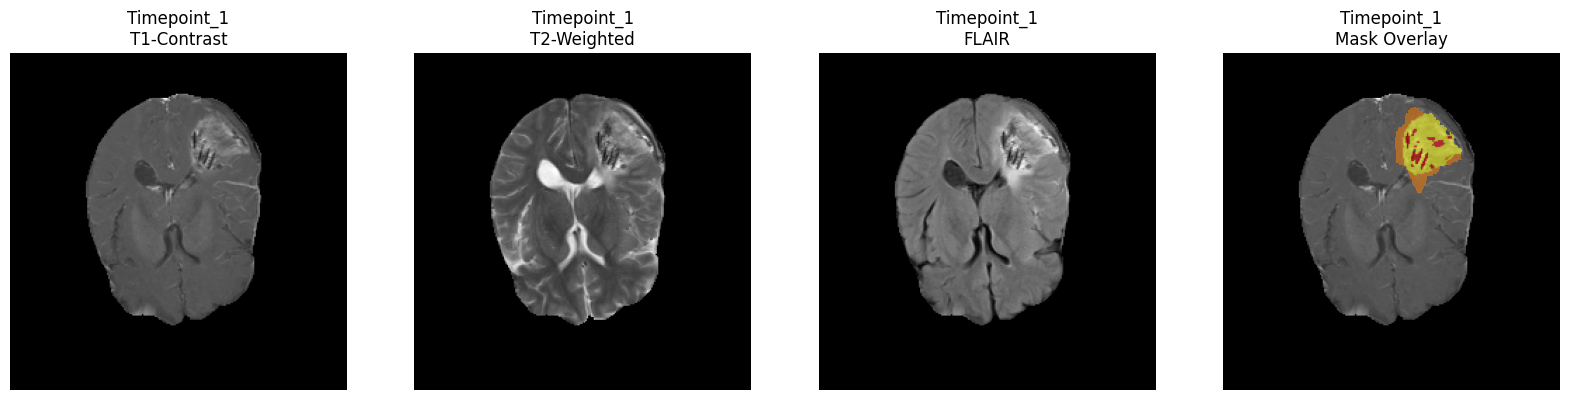

📊 VOLUMES for Timepoint_1:
   └─ Necrotic Tumor Core (Label1)       :       1.00 mm³
   └─ Tumor Infiltration and Edema       :       2.00 mm³
   └─ Enhancing Tumor Core (Label3)      :       3.00 mm³
   └─ Total_Tumor_cc                     :       6.00 mm³
📏 GRID SPECS: Matrix (240, 240, 155) | Voxel Δ (np.float32(1.0), np.float32(1.0), np.float32(1.0))
------------------------------------------------------------------------------------------------------------------------


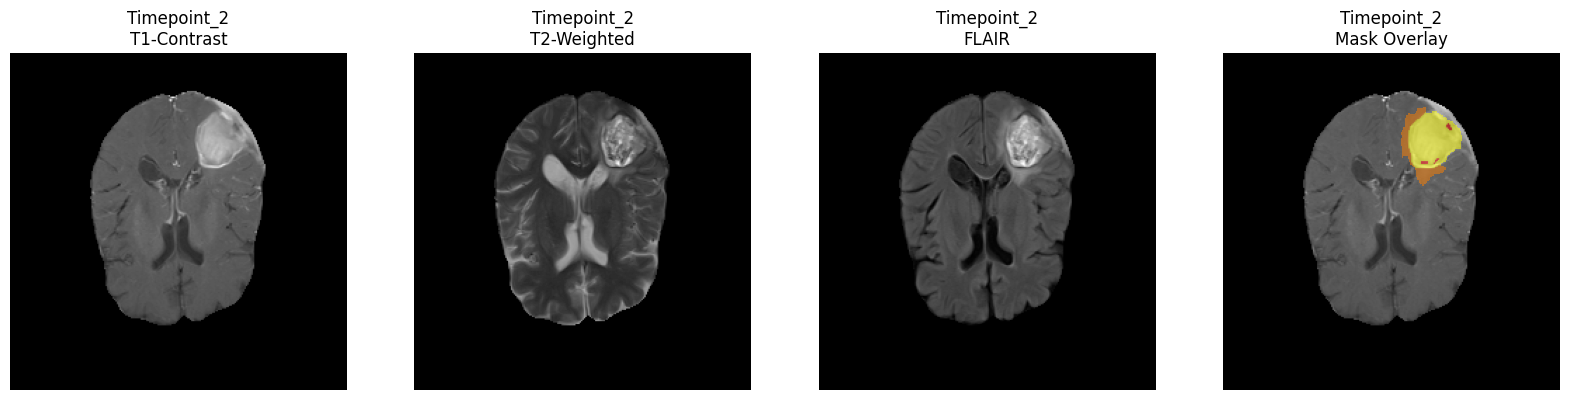

📊 VOLUMES for Timepoint_2:
   └─ Necrotic Tumor Core (Label1)       :       1.00 mm³
   └─ Tumor Infiltration and Edema       :       2.00 mm³
   └─ Enhancing Tumor Core (Label3)      :       3.00 mm³
   └─ Total_Tumor_cc                     :       6.00 mm³
📏 GRID SPECS: Matrix (240, 240, 155) | Voxel Δ (np.float32(1.0), np.float32(1.0), np.float32(1.0))
------------------------------------------------------------------------------------------------------------------------


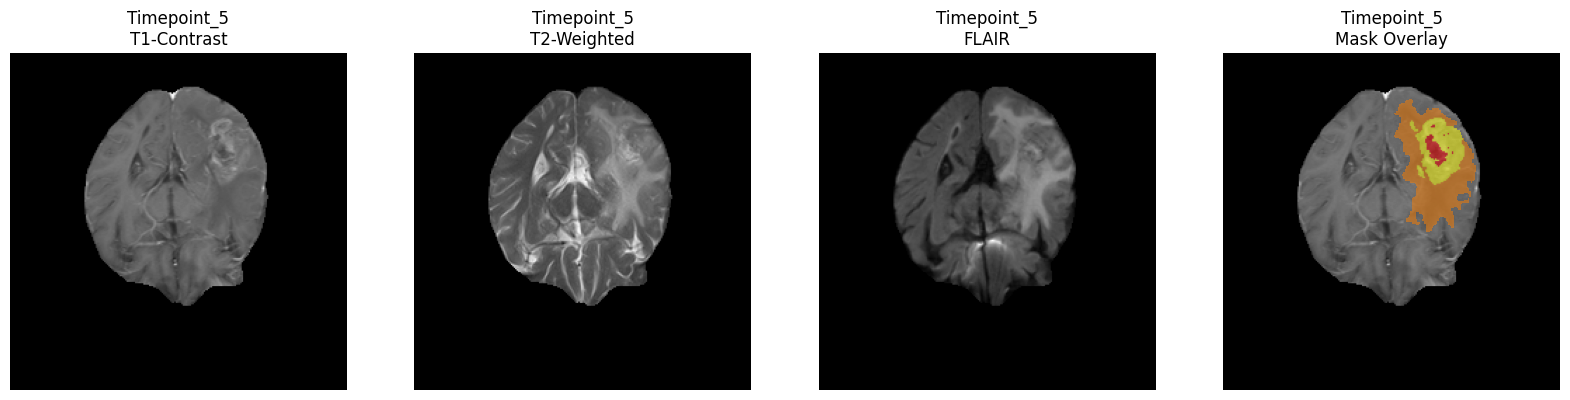

📊 VOLUMES for Timepoint_5:
   └─ Necrotic Tumor Core (Label1)       :       0.00 mm³
   └─ Tumor Infiltration and Edema       :       0.00 mm³
   └─ Enhancing Tumor Core (Label3)      :       0.00 mm³
   └─ Total_Tumor_cc                     :       0.00 mm³
📏 GRID SPECS: Matrix (240, 240, 155) | Voxel Δ (np.float32(1.0), np.float32(1.0), np.float32(1.0))
------------------------------------------------------------------------------------------------------------------------

🧬 NODE-PINN TRAINING DATA AUDIT: PatientID_0004


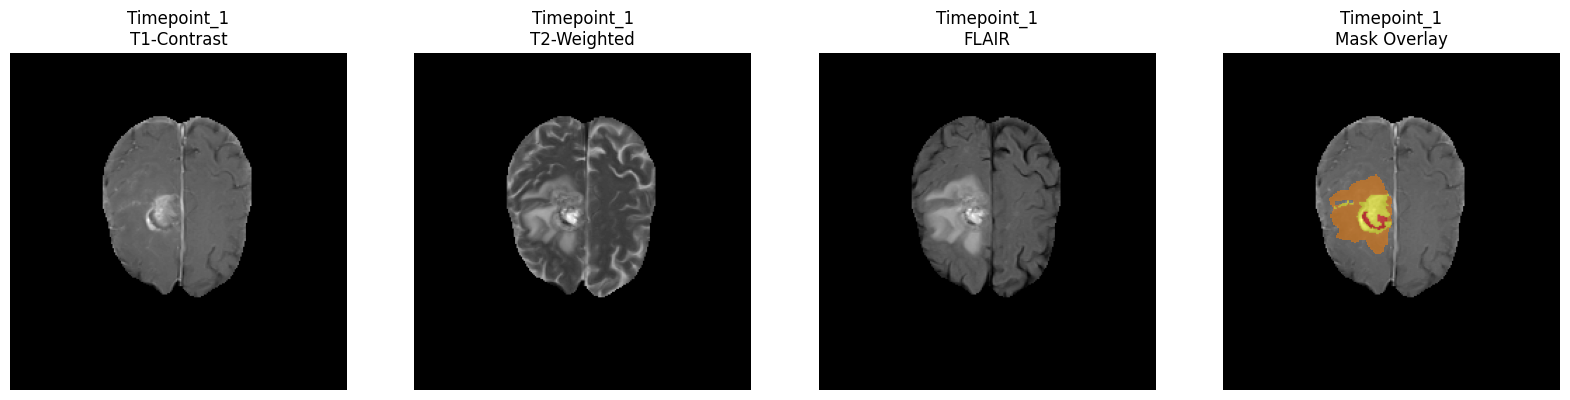

📊 VOLUMES for Timepoint_1:
   └─ Necrotic Tumor Core (Label1)       :       1.00 mm³
   └─ Tumor Infiltration and Edema       :       2.00 mm³
   └─ Enhancing Tumor Core (Label3)      :       3.00 mm³
   └─ Resection Cavity (Label4)          :       4.00 mm³
   └─ Total_Tumor_cc                     :       6.00 mm³
📏 GRID SPECS: Matrix (240, 240, 155) | Voxel Δ (np.float32(1.0), np.float32(1.0), np.float32(1.0))
------------------------------------------------------------------------------------------------------------------------

🧬 NODE-PINN TRAINING DATA AUDIT: PatientID_0005


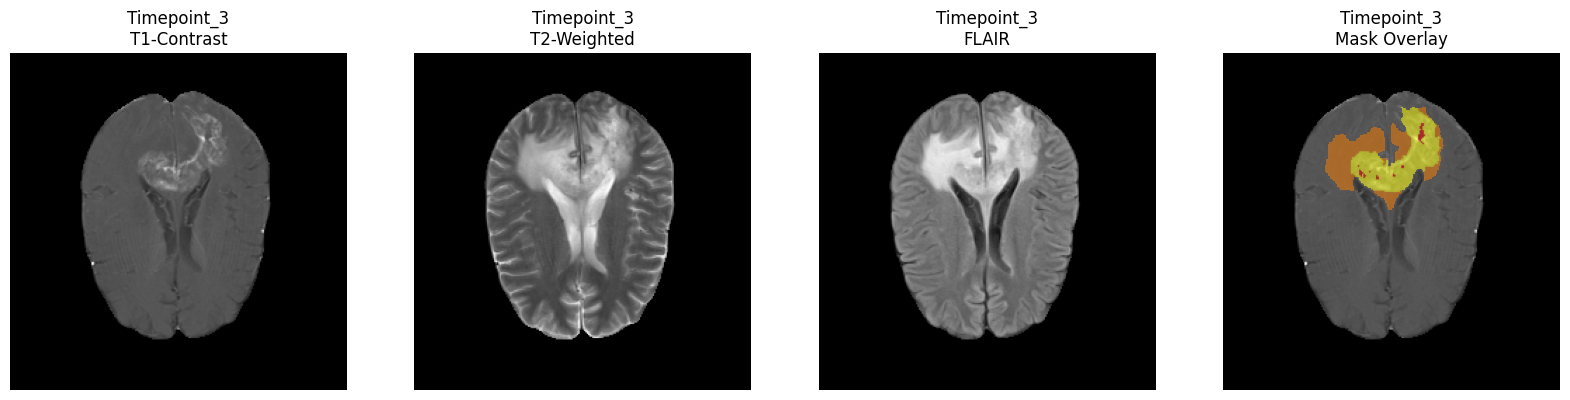

📊 VOLUMES for Timepoint_3:
   └─ Necrotic Tumor Core (Label1)       :       0.00 mm³
   └─ Tumor Infiltration and Edema       :       0.00 mm³
   └─ Enhancing Tumor Core (Label3)      :       0.00 mm³
   └─ Total_Tumor_cc                     :       0.00 mm³
📏 GRID SPECS: Matrix (240, 240, 155) | Voxel Δ (np.float32(1.0), np.float32(1.0), np.float32(1.0))
------------------------------------------------------------------------------------------------------------------------


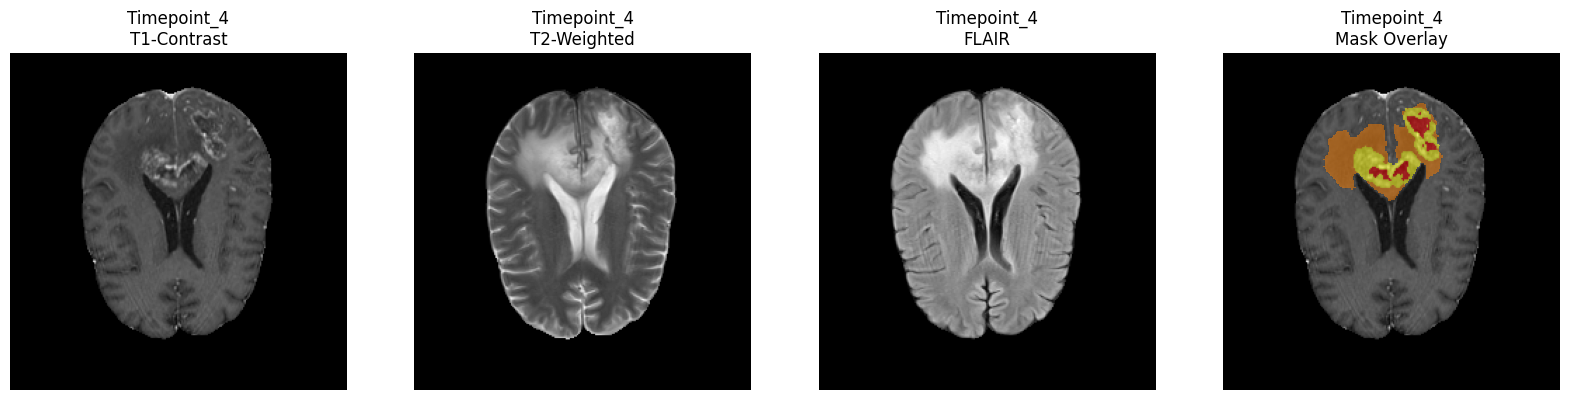

📊 VOLUMES for Timepoint_4:
   └─ Necrotic Tumor Core (Label1)       :       0.00 mm³
   └─ Tumor Infiltration and Edema       :       0.00 mm³
   └─ Enhancing Tumor Core (Label3)      :       0.00 mm³
   └─ Total_Tumor_cc                     :       0.00 mm³
📏 GRID SPECS: Matrix (240, 240, 155) | Voxel Δ (np.float32(1.0), np.float32(1.0), np.float32(1.0))
------------------------------------------------------------------------------------------------------------------------


In [25]:
# =============================================================================
# 4. VISUALIZATION AUDIT: MULTIMODAL IMAGES + SEGMENTATION VOLUMES
# =============================================================================

import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def show_vht_training_data(pid):
    obj = patient_objects.get(pid)
    if not obj or not obj['timepoints']:
        print(f"⚠️ No data found for {pid}")
        return

    print(f"\n{'='*120}")
    print(f"🧬 NODE-PINN TRAINING DATA AUDIT: {pid}")
    print(f"{'='*120}")

    for tp in obj['timepoints']:
        tp_vols = obj['volumes'].get(tp, {})
        tp_images = obj['images'].get(tp, [])
        
        # Identify sequences for the grid
        t1c_path = next((f for f in tp_images if 't1c' in f.lower()), None)
        t2_path = next((f for f in tp_images if 't2w' in f.lower()), None)
        flair_path = next((f for f in tp_images if 't2f' in f.lower()), None)
        mask_path = next((f for f in tp_images if 'mask' in f.lower()), None)
        
        sequences = [t1c_path, t2_path, flair_path]
        titles = ['T1-Contrast', 'T2-Weighted', 'FLAIR']
        
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
        # Use Mask to find the slice with the largest tumor cross-section
        if mask_path:
            mask_nib = nib.load(mask_path)
            mask_data = mask_nib.get_fdata()
            slice_idx = np.argmax(np.sum(mask_data, axis=(0, 1)))
        else:
            slice_idx = 75 # Fallback
            
        # Plot sequences
        for i, (path, title) in enumerate(zip(sequences, titles)):
            if path:
                data = nib.load(path).get_fdata()
                axes[i].imshow(np.rot90(data[:, :, slice_idx]), cmap='gray')
                axes[i].set_title(f"{tp}\n{title}")
            else:
                axes[i].text(0.5, 0.5, 'Missing', ha='center')
            axes[i].axis('off')
            
        # Plot Mask Overlay on T1c
        if t1c_path and mask_path:
            t1c_data = nib.load(t1c_path).get_fdata()
            axes[3].imshow(np.rot90(t1c_data[:, :, slice_idx]), cmap='gray')
            masked_roi = np.ma.masked_where(mask_data <= 0, mask_data)
            axes[3].imshow(np.rot90(masked_roi[:, :, slice_idx]), cmap='autumn', alpha=0.5)
            axes[3].set_title(f"{tp}\nMask Overlay")
        axes[3].axis('off')
        
        plt.show()

        # Print detailed metadata and volumes for the NODE-PINN loss function
        print(f"📊 VOLUMES for {tp}:")
        if tp_vols:
            for label, val in tp_vols.items():
                print(f"   └─ {label:35}: {val:>10,.2f} mm³")
        else:
            print("   ❌ No volume data found.")
            
        if t1c_path:
            hdr = nib.load(t1c_path).header
            print(f"📏 GRID SPECS: Matrix {hdr.get_data_shape()} | Voxel Δ {hdr.get_zooms()}")
        print("-" * 120)

# Run for all patients or specific IDs
for pid in list(patient_objects.keys())[:3]: # Adjust range as needed
    show_vht_training_data(pid)

This code implements a multimodal longitudinal audit that integrates raw 3D NIfTI imaging with segmented volume data to validate the structural and temporal integrity of each patient object before training. It uses a "smart-slicing" algorithm to identify the peak tumor cross-section across multiple MRI sequences (T1c, T2, FLAIR), overlaying physiological masks to verify that the ground-truth segmentations align with the anatomical reality. By extracting critical metadata—such as voxel spacing and matrix dimensions—the script ensures that the spatial grid is physically calibrated for PINN Laplacian calculations and that the temporal labels are properly synchronized for Neural ODE integration.

In [ ]:
# Clinical Data - Load and set index to Patient ID
clinical_data_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx"
clinical_reader = pd.ExcelFile(clinical_data_path)

# Load the specific sheet and SET THE INDEX to Patient ID
clin_key = clinical_reader.sheet_names[1] 
clinical_df = pd.read_excel(clinical_data_path, sheet_name=clin_key)
clinical_df.columns = clinical_df.columns.str.strip() 
clinical_df = clinical_df.set_index('Patient ID') 

patient_objects = {}

for pid in patient_ids:
    patient_obj = {
        'Patient_ID': pid,
        'biomarkers': {},         
        'treatment': {},          
        'temporal_alignment': {}, 
        'trajectories': {},       
        'outcomes': {},           
        'timepoints': []
    }
    
    # A. Extract ALL VHT Features from clinical_df
    # FIX: Use clinical_df instead of clinical_data[clin_key]
    if pid in clinical_df.index:
        clin_row = clinical_df.loc[pid]
        
        # Handle cases where a PID might appear twice in the Excel
        if isinstance(clin_row, pd.DataFrame):
            clin_row = clin_row.iloc[0]
        
        # 1. BIOMARKERS (Priors)
        patient_obj['biomarkers'] = {
            'Sex': clin_row.get('Sex at Birth'),
            'Age_at_Diagnosis': clin_row.get('Age at diagnosis'),
            'Primary_Diagnosis': clin_row.get('Primary Diagnosis'),
            'Tumor_Grade': clin_row.get('Grade of Primary Brain Tumor'),
            'IDH1': clin_row.get('IDH1 mutation'),
            'IDH2': clin_row.get('IDH2 mutation'),
            '1p19q': clin_row.get('1p/19q'),
            'MGMT': clin_row.get('MGMT methylation'),
            'ATRX': clin_row.get('ATRX mutation'),
            'TERT': clin_row.get('TERT promoter mutation'),
            'EGFR': clin_row.get('EGFR amplification'),
            'PTEN': clin_row.get('PTEN mutation'),
            'CDKN2A_B': clin_row.get('CDKN2A/B deletion'),
            'TP53': clin_row.get('TP53 alteration')
        }
        
        # 2. TREATMENT (Mechanistic Inputs)
        # Note: Added leading spaces to some keys to match the Excel's hidden formatting
        patient_obj['treatment'] = {
            'First_Surgery_Days': clin_row.get('Number of days from Diagnosis to First surgery or procedure'),
            'Multiple_Surgeries': clin_row.get('Multiple surgeries'),
            'Radiation': clin_row.get('Radiation Therapy'),
            'RT_Start_Days': clin_row.get('Number of days from Diagnosis to Radiation Therapy Start date'),
            'RT_End_Days': clin_row.get('Number of days from Diagnosis to Radiation Therapy end date'),
            'RT_Dose_Gy': clin_row.get('Dose'),
            'RT_Fractions': clin_row.get('Number of Fractions'),
            'Chemo': clin_row.get('Initial Chemo Therapy'),
            'Chemo_Name': clin_row.get('Name of Initial Chemo Therapy'),
            'Chemo_Start_Days': clin_row.get(' Number of days from Diagnosis to Initial Chemo Therapy Start date'),
            'Chemo_End_Days': clin_row.get(' Number of days from Diagnosis to Initial Chemo Therapy end date'),
            'Additional_Therapy': clin_row.get('Additional Therapy')
        }
        
        # 3. TEMPORAL ALIGNMENT (Days from Diagnosis per MRI scan)
        patient_obj['temporal_alignment'] = {
            'Timepoint_1': clin_row.get('Number of Days from Diagnosis to 1st MRI (Timepoint_1)'),
            'Timepoint_2': clin_row.get('Number of Days from Diagnosis to 2nd MRI (Timepoint_2)'),
            'Timepoint_3': clin_row.get('Number of Days from Diagnosis to 3rd MRI (Timepoint_3)'),
            'Timepoint_4': clin_row.get('Number of Days from Diagnosis to 4th MRI (Timepoint_4)'),
            'Timepoint_5': clin_row.get('Number of Days from Diagnosis to 5th MRI (Timepoint_5)'),
            'Timepoint_6': clin_row.get('Number of Days from Diagnosis to 6th MRI (Timepoint_6)')
        }

        # 4. OUTCOMES (Validation Data)
        patient_obj['outcomes'] = {
            'Progression': clin_row.get('Progression'),
            'Time_to_Progression': clin_row.get('Time to First Progression (Days)'),
            'OS_Status': clin_row.get('Overall Survival (Death)'),
            'Days_to_Death': clin_row.get('Number of days from Diagnosis to death (Days)'),
            'Hospice': clin_row.get('Hospice')
        }
    
    # B. Map Image structure + timepoints (from folder names)
    patient_folder = Path(image_data_path) / pid
    if patient_folder.exists():
        found_tps = sorted([t.name for t in patient_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
        patient_obj['timepoints'] = found_tps
    
    # C. Map Longitudinal Volumes using Generated Timepoints
    for tp in patient_obj['timepoints']:
        tp_volumes = {}
        for sheet_name, df in volume_data.items():
            if pid in df.index:
                patient_rows = df.loc[[pid]] 
                match = patient_rows[patient_rows['Timepoint'] == tp]
                
                if not match.empty:
                    # Capture the volume column dynamically
                    vol_cols = [c for c in match.columns if 'Volume' in c or 'Vol' in c]
                    if vol_cols:
                        tp_volumes[sheet_name] = match.iloc[0][vol_cols[0]]
        
        if tp_volumes:
            # Mechanistic total: Necrotic + Edema + Enhancing (excludes Resection Label 4)
            core_vals = [v for k, v in tp_volumes.items() if 'Label4' not in k and 'Resection' not in k]
            tp_volumes['Total_Tumor_Volume'] = sum(core_vals)
            patient_obj['trajectories'][tp] = tp_volumes

    patient_objects[pid] = patient_obj

print(f"Created {len(patient_objects)} Patient Objects with the full {len(list(patient_obj['biomarkers'].keys()) + list(patient_obj['treatment'].keys()) + list(patient_obj['temporal_alignment'].keys()) + list(patient_obj['outcomes'].keys()) + list(patient_obj['trajectories'].keys()))}-feature VHT mapping.")

Created 203 Patient Objects with the full 37-feature VHT mapping.


In [ ]:
# =============================================================================
# 4. UNIFIED PATIENT OBJECT INTEGRATION (CLINICAL + IMAGES + VOLUMES)
# =============================================================================
patient_objects = {}

for pid in patient_ids:
    # Initialize the structured object
    patient_obj = {
        'Patient_ID': pid,
        'biomarkers': {},         # 🧬 Biological/Molecular Priors
        'treatment': {},          # ⚡ Mechanistic Perturbations
        'temporal_alignment': {}, # ⏱️ Time (t) for Neural ODEs
        'outcomes': {},           # 🎯 Ground Truth / Prediction
        'timepoints': [],        # 📅 Found in Folders
        'image_paths': {},       # 📂 NIfTI File Names
        'trajectories': {}        # 📏 Volumetric States
    }
    
    # --- PART A: INTEGRATE CLINICAL DATA ---
    if pid in clinical_df.index:
        clin_row = clinical_df.loc[pid]
        if isinstance(clin_row, pd.DataFrame):
            clin_row = clin_row.iloc[0]
        
        # 1. BIOMARKERS (Priors)
        patient_obj['biomarkers'] = {
            'Sex': clin_row.get('Sex at Birth'),
            'Age_at_Diagnosis': clin_row.get('Age at diagnosis'),
            'Primary_Diagnosis': clin_row.get('Primary Diagnosis'),
            'Tumor_Grade': clin_row.get('Grade of Primary Brain Tumor'),
            'IDH1': clin_row.get('IDH1 mutation'),
            'IDH2': clin_row.get('IDH2 mutation'),
            '1p19q': clin_row.get('1p/19q'),
            'MGMT': clin_row.get('MGMT methylation'),
            'ATRX': clin_row.get('ATRX mutation'),
            'TERT': clin_row.get('TERT promoter mutation'),
            'EGFR': clin_row.get('EGFR amplification'),
            'PTEN': clin_row.get('PTEN mutation'),
            'CDKN2A_B': clin_row.get('CDKN2A/B deletion'),
            'TP53': clin_row.get('TP53 alteration')
        }
        
        # 2. TREATMENT (Mechanistic Inputs)
        # Note: Added leading spaces to some keys to match the Excel's hidden formatting
        patient_obj['treatment'] = {
            'First_Surgery_Days': clin_row.get('Number of days from Diagnosis to First surgery or procedure'),
            'Multiple_Surgeries': clin_row.get('Multiple surgeries'),
            'Radiation': clin_row.get('Radiation Therapy'),
            'RT_Start_Days': clin_row.get('Number of days from Diagnosis to Radiation Therapy Start date'),
            'RT_End_Days': clin_row.get('Number of days from Diagnosis to Radiation Therapy end date'),
            'RT_Dose_Gy': clin_row.get('Dose'),
            'RT_Fractions': clin_row.get('Number of Fractions'),
            'Chemo': clin_row.get('Initial Chemo Therapy'),
            'Chemo_Name': clin_row.get('Name of Initial Chemo Therapy'),
            'Chemo_Start_Days': clin_row.get(' Number of days from Diagnosis to Initial Chemo Therapy Start date'),
            'Chemo_End_Days': clin_row.get(' Number of days from Diagnosis to Initial Chemo Therapy end date'),
            'Additional_Therapy': clin_row.get('Additional Therapy')
        }
        
        # 3. TEMPORAL ALIGNMENT (Days from Diagnosis per MRI scan)
        patient_obj['temporal_alignment'] = {
            'Timepoint_1': clin_row.get('Number of Days from Diagnosis to 1st MRI (Timepoint_1)'),
            'Timepoint_2': clin_row.get('Number of Days from Diagnosis to 2nd MRI (Timepoint_2)'),
            'Timepoint_3': clin_row.get('Number of Days from Diagnosis to 3rd MRI (Timepoint_3)'),
            'Timepoint_4': clin_row.get('Number of Days from Diagnosis to 4th MRI (Timepoint_4)'),
            'Timepoint_5': clin_row.get('Number of Days from Diagnosis to 5th MRI (Timepoint_5)'),
            'Timepoint_6': clin_row.get('Number of Days from Diagnosis to 6th MRI (Timepoint_6)')
        }

        # 4. OUTCOMES (Validation Data)
        patient_obj['outcomes'] = {
            'Progression': clin_row.get('Progression'),
            'Time_to_Progression': clin_row.get('Time to First Progression (Days)'),
            'OS_Status': clin_row.get('Overall Survival (Death)'),
            'Days_to_Death': clin_row.get('Number of days from Diagnosis to death (Days)'),
            'Hospice': clin_row.get('Hospice')
        }

    # --- PART B: INTEGRATE IMAGE STRUCTURE ---
    patient_folder = Path(image_data_path) / pid
    if patient_folder.exists():
        found_tps = sorted([t.name for t in patient_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
        patient_obj['timepoints'] = found_tps
        
        for tp in found_tps:
            # Map NIfTI files
            tp_path = patient_folder / tp
            nifti_files = list(tp_path.glob("*.nii.gz"))
            patient_obj['image_paths'][tp] = [f.name for f in nifti_files]

            # --- PART C: INTEGRATE SEGMENTATION VOLUMES ---
            tp_volumes = {}
            for sheet_name, df_vol in volume_data.items():
                if pid in df_vol.index:
                    patient_rows = df_vol.loc[[pid]]
                    match = patient_rows[patient_rows['Timepoint'] == tp]
                    if not match.empty:
                        vol_cols = [c for c in match.columns if 'Volume' in c or 'Vol' in c]
                        if vol_cols:
                            tp_volumes[sheet_name] = match.iloc[0][vol_cols[0]]
            
            if tp_volumes:
                # Calculate Total Biological Tumor Volume
                core_vals = [v for k, v in tp_volumes.items() if 'Label4' not in k and 'Resection' not in k]
                tp_volumes['Total_Tumor_Volume'] = sum(core_vals)
                patient_obj['trajectories'][tp] = tp_volumes

    patient_objects[pid] = patient_obj

print(f"✅ Integrated {len(patient_objects)} complete patient objects.")

✅ Integrated 203 complete patient objects.


In [ ]:
def sanitize_vht_data(obj):
    """Recursively converts NumPy types to standard Python types for clean output."""
    if isinstance(obj, dict):
        return {k: sanitize_vht_data(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [sanitize_vht_data(i) for i in obj]
    elif isinstance(obj, (np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.float64, np.float32)):
        # Convert NaN to None for better readability in outcomes
        return float(obj) if not np.isnan(obj) else None
    else:
        return obj

# Apply the fix to your dictionary
for pid in patient_objects:
    patient_objects[pid] = sanitize_vht_data(patient_objects[pid])

print("✅ Data types standardized to Python primitives.")

for pid, data in patient_objects.items():
    print(f"\nPatient ID: {pid}")
    print(f"Biomarkers: {data['biomarkers']}")
    print(f"Treatment: {data['treatment']}")
    print(f"Temporal Alignment: {data['temporal_alignment']}")
    print(f"Outcomes: {data['outcomes']}")
    print(f"Timepoints: {data['timepoints']}")
    print(f"Image Paths: {data['image_paths']}")
    print(f"Trajectories: {data['trajectories']}")

✅ Data types standardized to Python primitives.

Patient ID: PatientID_0003
Biomarkers: {'Sex': 'Female', 'Age_at_Diagnosis': 57, 'Primary_Diagnosis': 'GBM', 'Tumor_Grade': 4, 'IDH1': 0, 'IDH2': 0, '1p19q': 0, 'MGMT': 4, 'ATRX': 4, 'TERT': 2, 'EGFR': 2, 'PTEN': 0, 'CDKN2A_B': 0, 'TP53': 0}
Treatment: {'First_Surgery_Days': -5, 'Multiple_Surgeries': 1, 'Radiation': 'Yes', 'RT_Start_Days': 17.0, 'RT_End_Days': 65.0, 'RT_Dose_Gy': '60 Gy', 'RT_Fractions': 30.0, 'Chemo': 'Yes', 'Chemo_Name': 'Temozolomide', 'Chemo_Start_Days': None, 'Chemo_End_Days': None, 'Additional_Therapy': 'Temozolomide'}
Temporal Alignment: {'Timepoint_1': 90.0, 'Timepoint_2': 146.0, 'Timepoint_3': None, 'Timepoint_4': None, 'Timepoint_5': 286.0, 'Timepoint_6': None}
Outcomes: {'Progression': 1, 'Time_to_Progression': 286.0, 'OS_Status': 0, 'Days_to_Death': None, 'Hospice': 1}
Timepoints: ['Timepoint_1', 'Timepoint_2', 'Timepoint_5']
Image Paths: {'Timepoint_1': ['PatientID_0003_Timepoint_1_brain_t1c.nii.gz', 'Patien

In [ ]:
# =============================================================================
# 5. DETAILED DATA INSPECTION LOOP (REPORTS ALL DATA)
# =============================================================================
print("\n🔍 FULL VHT PATIENT DATA AUDIT")
print("="*100)

for pid, obj in patient_objects.items():
    print(f"\n🆔 PATIENT ID: {pid}")
    
    # Show key biomarkers
    b = obj['biomarkers']
    print(f"🧬 Profile: {b.get('Sex')}, Age {b.get('Age_at_Diagnosis')} | IDH1: {b.get('IDH1')} | MGMT: {b.get('MGMT')}")
    
    if not obj['timepoints']:
        print("    ⚠️ No longitudinal folders found.")
    else:
        for tp in obj['timepoints']:
            days = obj['temporal_alignment'].get(tp, "N/A")
            print(f"\n    ⏱️ {tp} (Day {days}):")
            
            # Show Files
            files = obj['image_paths'].get(tp, [])
            print(f"      📂 Images: {', '.join(files) if files else 'None'}")
            
            # Show Volumes
            vols = obj['trajectories'].get(tp, {})
            if vols:
                v_list = [f"{k}: {v:,.1f}" for k, v in vols.items()]
                print(f"      📏 Volumes: { ' | '.join(v_list) }")
            else:
                print("      📏 Volumes: No segmentation data mapped.")

print("\n" + "="*100)


🔍 FULL VHT PATIENT DATA AUDIT

🆔 PATIENT ID: PatientID_0003
🧬 Profile: Female, Age 57 | IDH1: 0 | MGMT: 4

    ⏱️ Timepoint_1 (Day 90.0):
      📂 Images: PatientID_0003_Timepoint_1_brain_t1c.nii.gz, PatientID_0003_Timepoint_1_brain_t2w.nii.gz, PatientID_0003_Timepoint_1_brain_t1n.nii.gz, PatientID_0003_Timepoint_1_tumorMask.nii.gz, PatientID_0003_Timepoint_1_brain_t2f.nii.gz
      📏 Volumes: Necrotic Tumor Core (Label1): 6,510.0 | Tumor Infiltration and Edema: 44,251.0 | Enhancing Tumor Core (Label3): 33,779.0 | Total_Tumor_Volume: 84,540.0

    ⏱️ Timepoint_2 (Day 146.0):
      📂 Images: PatientID_0003_Timepoint_2_tumorMask.nii.gz, PatientID_0003_Timepoint_2_brain_t1n.nii.gz, PatientID_0003_Timepoint_2_brain_t2f.nii.gz, PatientID_0003_Timepoint_2_brain_t2w.nii.gz, PatientID_0003_Timepoint_2_brain_t1c.nii.gz
      📏 Volumes: Necrotic Tumor Core (Label1): 2,813.0 | Tumor Infiltration and Edema: 45,757.0 | Enhancing Tumor Core (Label3): 37,248.0 | Total_Tumor_Volume: 85,818.0

    ⏱️ Ti

In [ ]:
# 6. CREATE UNIFIED PATIENT OBJECTS
clinical_data_path = "/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx"
clinical_reader = pd.ExcelFile(clinical_data_path)

# Load the specific sheet and SET THE INDEX to Patient ID
clin_key = clinical_reader.sheet_names[1] 
clinical_df = pd.read_excel(clinical_data_path, sheet_name=clin_key)
clinical_df.columns = clinical_df.columns.str.strip() 
clinical_df = clinical_df.set_index('Patient ID') # <--- THIS IS CRUCIAL

patient_objects = {}

for pid in patient_ids:
    patient_obj = {
        'Patient_ID': pid,
        'biomarkers': {},         
        'treatment': {},          
        'temporal_alignment': {}, 
        'trajectories': {},       
        'outcomes': {},           
        'timepoints': []
    }
    
    # A. Extract ALL VHT Features from clinical_df
    # FIX: Use clinical_df instead of clinical_data[clin_key]
    if pid in clinical_df.index:
        clin_row = clinical_df.loc[pid]
        
        # Handle cases where a PID might appear twice in the Excel
        if isinstance(clin_row, pd.DataFrame):
            clin_row = clin_row.iloc[0]
        
        # 1. BIOMARKERS (Priors)
        patient_obj['biomarkers'] = {
            'Sex': clin_row.get('Sex at Birth'),
            'Age_at_Diagnosis': clin_row.get('Age at diagnosis'),
            'Primary_Diagnosis': clin_row.get('Primary Diagnosis'),
            'Tumor_Grade': clin_row.get('Grade of Primary Brain Tumor'),
            'IDH1': clin_row.get('IDH1 mutation'),
            'IDH2': clin_row.get('IDH2 mutation'),
            '1p19q': clin_row.get('1p/19q'),
            'MGMT': clin_row.get('MGMT methylation'),
            'ATRX': clin_row.get('ATRX mutation'),
            'TERT': clin_row.get('TERT promoter mutation'),
            'EGFR': clin_row.get('EGFR amplification'),
            'PTEN': clin_row.get('PTEN mutation'),
            'CDKN2A_B': clin_row.get('CDKN2A/B deletion'),
            'TP53': clin_row.get('TP53 alteration')
        }
        
        # 2. TREATMENT (Mechanistic Inputs)
        # Note: Added leading spaces to some keys to match the Excel's hidden formatting
        patient_obj['treatment'] = {
            'First_Surgery_Days': clin_row.get('Number of days from Diagnosis to First surgery or procedure'),
            'Multiple_Surgeries': clin_row.get('Multiple surgeries'),
            'Radiation': clin_row.get('Radiation Therapy'),
            'RT_Start_Days': clin_row.get('Number of days from Diagnosis to Radiation Therapy Start date'),
            'RT_End_Days': clin_row.get('Number of days from Diagnosis to Radiation Therapy end date'),
            'RT_Dose_Gy': clin_row.get('Dose'),
            'RT_Fractions': clin_row.get('Number of Fractions'),
            'Chemo': clin_row.get('Initial Chemo Therapy'),
            'Chemo_Name': clin_row.get('Name of Initial Chemo Therapy'),
            'Chemo_Start_Days': clin_row.get(' Number of days from Diagnosis to Initial Chemo Therapy Start date'),
            'Chemo_End_Days': clin_row.get(' Number of days from Diagnosis to Initial Chemo Therapy end date'),
            'Additional_Therapy': clin_row.get('Additional Therapy')
        }
        
        # 3. TEMPORAL ALIGNMENT (Days from Diagnosis per MRI scan)
        patient_obj['temporal_alignment'] = {
            'Timepoint_1': clin_row.get('Number of Days from Diagnosis to 1st MRI (Timepoint_1)'),
            'Timepoint_2': clin_row.get('Number of Days from Diagnosis to 2nd MRI (Timepoint_2)'),
            'Timepoint_3': clin_row.get('Number of Days from Diagnosis to 3rd MRI (Timepoint_3)'),
            'Timepoint_4': clin_row.get('Number of Days from Diagnosis to 4th MRI (Timepoint_4)'),
            'Timepoint_5': clin_row.get('Number of Days from Diagnosis to 5th MRI (Timepoint_5)'),
            'Timepoint_6': clin_row.get('Number of Days from Diagnosis to 6th MRI (Timepoint_6)')
        }

        # 4. OUTCOMES (Validation Data)
        patient_obj['outcomes'] = {
            'Progression': clin_row.get('Progression'),
            'Time_to_Progression': clin_row.get('Time to First Progression (Days)'),
            'OS_Status': clin_row.get('Overall Survival (Death)'),
            'Days_to_Death': clin_row.get('Number of days from Diagnosis to death (Days)'),
            'Hospice': clin_row.get('Hospice')
        }
    
    # B. Map Image structure + timepoints (from folder names)
    patient_folder = Path(image_data_path) / pid
    if patient_folder.exists():
        found_tps = sorted([t.name for t in patient_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
        patient_obj['timepoints'] = found_tps
    
    # C. Map Longitudinal Volumes using Generated Timepoints
    for tp in patient_obj['timepoints']:
        tp_volumes = {}
        for sheet_name, df in volume_data.items():
            if pid in df.index:
                patient_rows = df.loc[[pid]] 
                match = patient_rows[patient_rows['Timepoint'] == tp]
                
                if not match.empty:
                    # Capture the volume column dynamically
                    vol_cols = [c for c in match.columns if 'Volume' in c or 'Vol' in c]
                    if vol_cols:
                        tp_volumes[sheet_name] = match.iloc[0][vol_cols[0]]
        
        if tp_volumes:
            # Mechanistic total: Necrotic + Edema + Enhancing (excludes Resection Label 4)
            core_vals = [v for k, v in tp_volumes.items() if 'Label4' not in k and 'Resection' not in k]
            tp_volumes['Total_Tumor_Volume'] = sum(core_vals)
            patient_obj['trajectories'][tp] = tp_volumes

    patient_objects[pid] = patient_obj

print(f"Created {len(patient_objects)} Patient Objects with the full 44-feature VHT mapping.")

Created 203 Patient Objects with the full 44-feature VHT mapping.


In [ ]:
# 7. GENERATE VHT MASTER DATASET & TEMPORAL TRAJECTORIES
print("\n📊 FLATTENING DATA FOR VHT MODELING...")

master_rows = []
longitudinal_rows = []

for pid, obj in patient_objects.items():
    # --- A. Create Master Row (Static Features for Priors & Outcomes) ---
    row = {'Patient_ID': pid}
    
    # Unpack all sub-dictionaries into the main row
    row.update(obj['biomarkers'])
    row.update(obj['treatment'])
    row.update(obj['temporal_alignment'])
    row.update(obj['outcomes'])
    
    # Add baseline volumetric states (Timepoint_1)
    if 'Timepoint_1' in obj['trajectories']:
        v1 = obj['trajectories']['Timepoint_1']
        for label, vol in v1.items():
            clean_name = label.split('(')[0].strip().replace(' ', '_')
            row[f"Baseline_{clean_name}"] = vol
    
    row['Total_Scans_Available'] = len(obj['timepoints'])
    master_rows.append(row)
    
    # --- B. Create Longitudinal Table (Dynamic States for Neural ODEs) ---
    for tp in obj['timepoints']:
        if tp in obj['trajectories']:
            # Find the actual day value from temporal_alignment for this timepoint
            day_val = obj['temporal_alignment'].get(tp)
            
            long_row = {
                'Patient_ID': pid,
                'Timepoint': tp,
                'Days_from_Diagnosis': day_val,
                # Include key priors for easy grouping/plotting
                'IDH1': obj['biomarkers'].get('IDH1'),
                'MGMT': obj['biomarkers'].get('MGMT')
            }
            # Add all volumes for this specific timepoint
            long_row.update(obj['trajectories'][tp])
            longitudinal_rows.append(long_row)

# 1. Create Master DataFrame (The 'Input-Output' Matrix)
master_df = pd.DataFrame(master_rows)

# 2. Create Longitudinal DataFrame (The 'Growth' Matrix)
long_df = pd.DataFrame(longitudinal_rows)

# --- CLEANING & FINAL SUMMARY ---
# Remove any accidental artifacts in column names
master_df.columns = [c.replace('_Vol', '').strip() for c in master_df.columns]

print(f"\n✅ SUCCESS: Integrated {len(master_df)} Patients.")
print(f"📐 Master Shape (Priors/Outcomes): {master_df.shape}")
print(f"📈 Longitudinal Shape (Growth States): {long_df.shape}")

# Display the first few rows of the VHT Master Data
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n--- MASTER VHT DATAFRAME SAMPLE ---")
print(master_df.head())

print("\n--- GROWTH TRAJECTORY SAMPLE ---")
print(long_df.head(10))

# OPTIONAL: Save to CSV for the next stage of your thesis
# master_df.to_csv("VHT_Master_Data.csv", index=False)
# long_df.to_csv("VHT_Longitudinal_Trajectories.csv", index=False)


📊 FLATTENING DATA FOR VHT MODELING...

✅ SUCCESS: Integrated 203 Patients.
📐 Master Shape (Priors/Outcomes): (203, 22)
📈 Longitudinal Shape (Growth States): (382, 10)

--- MASTER VHT DATAFRAME SAMPLE ---
       Patient_ID     Sex  Age  IDH1  MGMT  EGFR  1p19q RT_Dose  RT_Fractions Chemo  Surgery_Days  T1_Days  T2_Days  T3_Days  Progression  OS_Days  Baseline_Necrotic_Tumor_Core  Baseline_Tumor_Infiltration_and_Edema  Baseline_Enhancing_Tumor_Core  Baseline_Total_Tumorume  Total_Scans_Available  Baseline_Resection_Cavity
0  PatientID_0003  Female   57     0     4     2      0   60 Gy          30.0   Yes            -5     90.0    146.0      NaN            1      NaN                        6510.0                                44251.0                        33779.0                  84540.0                      3                        NaN
1  PatientID_0004  Female   67     0     4     2     10     NaN           NaN   NaN            -4     67.0      NaN      NaN            0      NaN     